# MVP: Análise de Dados e Boas Práticas - Pós-Graduação PUC-RIO
### Projeto apresentado como atividade final da Sprint Análise de Dados e Boas Práticas

**Autor:** Rogério dos Santos Ferreira  
**Matrícula:** 4052025001195  
**Data:** 04/04/2026

**Dataset:** [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)  
Quais fatores contribuem para a satisfação do cliente em uma companhia aérea?

Link para execução pelo Google Colab:  
<a href="https://colab.research.google.com/github/rogerioferreira/MVP-Analise-de-Dados-e-Boas-Praticas-PUC-RIO/blob/master/notebooks/mvp-analise%20de%20dados%20e%20boas%20praticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="page-break-after: always;"></div>  

# 1. Definição do Problema

O objetivo deste projeto é a realização da Análise de Dados de um dataset acerca da satisfação geral de clientes em relação aos serviços prestados por companhias aéreas, de forma a verificar a existência de possíveis correlações entre os seus atributos e identificar medidas mitigatórias para o problema de insatisfação. Além da análise citada, os dados serão preparados para o treinamento de modelos de Machine Learning, destinados à classificação dos clientes em graus de satisfação geral ("Satisfeito" ou  "Neutro ou Insatisfeito"), com base em seus atributos sócio-demográficos, no tipo de serviço contratado (classe) e no resultado da aplicação de questionário de satisfação acerca da percepção de qualidade de detrminados serviços prestados pelas companhias.

## Hipóteses Levantadas

1. A Classe Econômica impacta diretamente na satisfação do cliente? (grau de correlação?)

2. O Tipo da Viagem impacta diretamente na satisfação final do cliente? (grau de correlação?)

3. Qual serviço possui maior influência na satisfação final do cliente?

4. Existem diferenças na percepção de satisfação por gênero ou faixa etária?

## Tipo do Problema

O problema em questão trata-se da construção de um modelo de Machine Learning para a **Classificação Supervisionada** do grau de satisfação geral de clientes de uma companhia aérea com base em um conjunto de informações sócio-demográficas e resultados de consultas de satisfação específicas.

## Seleção de Dados

O Dataset utilizado foi obtido diretamente na plataforma Kaggle, não havendo necessidade de seleção de dados externos. O mesmo encontra-se disponível no endereço [Kaggle - Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction).

## Atributos do Dataset

O Dataset utilizado neste projeto contém **129.880 amostras**, sedo as mesmas compostas de **23 atributos**, os quais são descritos a seguir:

| **ATRIBUTO** | **DESCRIÇÃO** |
| :--- | :--- |
| **Gender**: | Gênero dos passageiros (Feminino, Masculino) |
| **Customer Type**: | O tipo de cliente (Regular, Esporádico) |
| **Age**: | Idade atual dos passageiros |
| **Type of Travel**: | Objetivo do voo (Viagem Pessoal, Viagem de Negócios) |
| **Class**: | Classe da viagem (Executiva, Econômica, Econômica Plus) |
| **Flight distance**: | Distância de voo em Milhas |
| **Inflight wifi service**: | Nível de satisfação com o serviço de Wi-Fi a bordo (0: Não aplicável; 1-5) |
| **Departure/Arrival time convenient**: | Nível de satisfação com a conveniência do horário de partida/chegada |
| **Ease of Online booking**: | Nível de satisfação com a facilidade da reserva online |
| **Gate location**: | Nível de satisfação com a localização do portão |
| **Food and drink**: | Nível de satisfação com comida e bebida |
| **Online boarding**: | Nível de satisfação com o check-in (embarque) online |
| **Seat comfort**: | Nível de satisfação com o conforto do assento |
| **Inflight entertainment**: | Nível de satisfação com o entretenimento de bordo |
| **On-board service**: | Nível de satisfação com o serviço de bordo |
| **Leg room service**: | Nível de satisfação com o espaço para as pernas |
| **Baggage handling**: | Nível de satisfação com o manuseio de bagagem |
| **Check-in service**: | Nível de satisfação com o serviço de check-in |
| **Inflight service**: | Nível de satisfação com o serviço de bordo (atendimento da tripulação) |
| **Cleanliness**: | Nível de satisfação com a limpeza |
| **Departure Delay in Minutes**: | Minutos de atraso no momento da partida |
| **Arrival Delay in Minutes**: | Minutos de atraso no momento da chegada |
| **Satisfaction**: | Nível de satisfação com a companhia aérea (Satisfeito, Neutro ou Insatisfeit |


<div style="page-break-after: always;"></div>  

# 2. Obtenção dos Dados

## Importação das Bibliotecas e padronizaçãoes

Nesta etapa será consolidada a importação de todas as bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, visando facilitar a identificação de possíveis falhas nos requisitos e a solução de problemas desta natureza. Além disso, será realizada nesta fase a padronização visual das visualizações gráficas empregadas no projeto, buscando uma construção estética mais adequada para facilitra a compreensão das análises realizadas.

In [68]:
# Importação das bibliotecas necessárias para o projeto
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

# Padronização do estilo dos gráficos para melhor apresentação
sns.set_theme(
    style="darkgrid",
    context="paper",
    palette="deep",
    font_scale=1.1,
)

## Carga de Dados

Tendo em vista que os dados empregados no projeto são oriundo de uma única fonte, já no formato CSV, faz-se necessária apenas a carga do mesmo. Contudo, como os dados encontram-se originalmente separados em dados de treino e teste, foi realizada a combinação do mesmo para a realização dos processos de análise e tratamento de forma adequada.

In [69]:
# Definição dos caminhos para os arquivos de dados locais
data_train_path = Path("../dados/originais/Airline Passenger Satisfaction - train.csv")
data_test_path = Path("../dados/originais/Airline Passenger Satisfaction - test.csv")

# Verificação da existência dos arquivos locais e carga dos dados, com fallback para URLs se os arquivos não estiverem disponíveis
# Medida necessária para garantir a carga de dados no Google Colab
if data_train_path.exists() and data_test_path.exists():
    train_data = pd.read_csv(
        "../dados/originais/Airline Passenger Satisfaction - train.csv", index_col=0
    )
    test_data = pd.read_csv(
        "../dados/originais/Airline Passenger Satisfaction - test.csv", index_col=0
    )
else:
    train_data = pd.read_csv(
        "https://raw.githubusercontent.com/rogerioferreira/MVP-Analise-de-Dados-e-Boas-Praticas-PUC-RIO/refs/heads/master/dados/originais/Airline%20Passenger%20Satisfaction%20-%20train.csv",
        index_col=0,
    )
    test_data = pd.read_csv(
        "https://raw.githubusercontent.com/rogerioferreira/MVP-Analise-de-Dados-e-Boas-Praticas-PUC-RIO/refs/heads/master/dados/originais/Airline%20Passenger%20Satisfaction%20-%20test.csv",
        index_col=0,
    )


# Combinação dos dados de treinamento e teste em um único DataFrame para análise exploratória
data = pd.concat([train_data, test_data], ignore_index=True)

<div style="page-break-after: always;"></div>  

# 3. Limpeza e tratamento inicial dos dados

Nesta etapa foram realizados procedimentos iniciais de tratamento de dados visando aprimorar a etapa de análise exploratória. Como parate do processo foi removida a coluna "ID" do datase, tendo em vista não possuir relevância para a nálise dos dados ou para o treinamento do modelo.

In [70]:
# Remoção da coluna ID por não possuir relevância para a análise
data.drop(columns=["id"], inplace=True)

## Criação de novas variáveis

Por meio do atributo "Age", que originalmente trata-se de uma variável numérica discreta, foi construída um outra variável categórica, nominada "Age Group", subdividindo-se o conjunto em cinco faixas etárias ("0-17", "18-30", "31-50", "51-65", "65+").

In [71]:
# Criação de nova variável categórica "Age Group" a partir da variável numérica "Age"

# Definição dos bins e labels para categorizar as idades em grupos etários
bins = [0, 18, 31, 51, 66, 100]
labels = [
    "0-17",
    "18-30",
    "31-50",
    "51-65",
    "65+",
]
data["Age Group"] = pd.cut(data["Age"], bins=bins, labels=labels, right=False)

# Reordenação das colunas para melhor organização
# Trazendo as colunas categóricas para o início do dataframe (exceto a variável alvo)
categorical_cols = [
    "Gender",
    "Age Group",
    "Customer Type",
    "Type of Travel",
    "Class",
]
numerical_cols = [col for col in data.columns if col not in categorical_cols]
data = data[categorical_cols + numerical_cols]

## Verificação de dados duplicados

Em seguida foi realizada a verificação da ocorrência de duplicidade de dados no dataset, visando a eliminação de dados redundantes que possam vir a interferir na análise dos dados e no treinamento do modelo.

A existência de duplicatas pode causar um fenômeno de sobreajuste (overfitting) direcionado a instâncias específicas. Quando o mesmo exemplo aparece múltiplas vezes, o algoritmo de aprendizagem tende a atribuir um peso desproporcional a essa observação, "memorizando" o ruído ou características particulares daquele dado em vez de aprender padrões generalizáveis (GÉRON, 2019, p. 27). Isso resulta em um modelo que apresenta alta performance nos dados de treino, mas falha ao lidar com dados novos e não vistos (HUYEN, 2022, p. 137).

Contudo, observa-se na análise abaixo que o dataset empregado neste projeto não possui valores duplicados.

In [72]:
dup = data.duplicated().sum()
print(f"Número de linhas duplicadas: {dup}")

Número de linhas duplicadas: 0


In [73]:
# Primeiras linhas do dataset
data.head(3)

,Gender,Age Group,Customer Type,Type of Travel,Class,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,0-17,Loyal Customer,Personal Travel,Eco Plus,13,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,18-30,disloyal Customer,Business travel,Business,25,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,18-30,Loyal Customer,Business travel,Business,26,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied


<div style="page-break-after: always;"></div>  

# 4. Análise Exploratória de Dados (EDA)

Nesta etapa de Análise Exploratória de Dados (EDA) sobre o Dataset, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Quantitativo de Amostras e Tipo de Atributos

O Dataset utilizado no projeto, após a etapa de tratamento inicial dos dados, na qual foi criada a variável categórica "Age Group", passou a ser composto de **129.880 amostras** e **24 atributos**. Dos atributos constantes no conjunto de dados 17 são do tipo inteiro (int64), um atributo ("Arrival Delay") é do tipo ponto flutuante (float64) e 6 atributos ("Gender", "Age Group", "Customer Type", "Type of Travel", "Class" e "satisfaction") são categóricos (category/object), como pode ser observado no resumo abaixo:

In [74]:
print(f"Total de instâncias: {len(data)}")
print("\nTipos de dados por coluna:")
print(data.info())

Total de instâncias: 129880

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   Gender                             129880 non-null  object  
 1   Age Group                          129880 non-null  category
 2   Customer Type                      129880 non-null  object  
 3   Type of Travel                     129880 non-null  object  
 4   Class                              129880 non-null  object  
 5   Age                                129880 non-null  int64   
 6   Flight Distance                    129880 non-null  int64   
 7   Inflight wifi service              129880 non-null  int64   
 8   Departure/Arrival time convenient  129880 non-null  int64   
 9   Ease of Online booking             129880 non-null  int64   
 10  Gate location                      1

## Distribuição da Variável Alvo

Analisando o gráfico abaixo, podemos observar que a variável alvo "satisfaction" apresenta um pequeno nível de desbalanceamento entre as classes "satisfied" e "neutral ou dissatisfied". Embora não exista um valor fixo universal na literatura técnica para classificar um variável como desbalanceada, a severidade do desbalanceamento é comumente categorizada com base na proporção da classe minoritária em relação ao total da amostra. Para tanto, considera-se um desbalanceamento leve quando a classe minoritária representa entre 20% e 40% do conjunto de dados (HUYEN, 2022, p. 229).

Contudo, com base nos valores observados, a classe minoritária encontra-se acima dos padrões definidos pela literatura técnica para um desbalanceamanto leve, apresentando um percentual de 43% do quantitativo total da variável, podendo desta forma ser descartada a necessidade de intervenção para balanceamento da mesma, sem prejuízo para a construção do modelo de classificação desejado.

satisfaction
neutral or dissatisfied    0.5655
satisfied                  0.4345
Name: proportion, dtype: float64


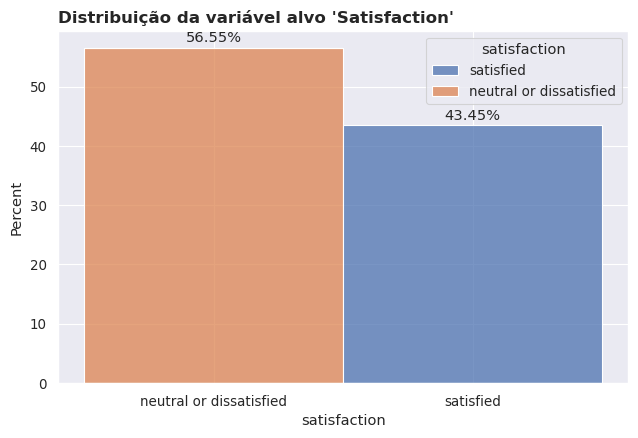

In [75]:
plt.figure(figsize=(6.5, 4.5))

ax = sns.histplot(
    data=data,
    x="satisfaction",
    hue="satisfaction",
    stat="percent",
    multiple="stack",
    hue_order=["satisfied", "neutral or dissatisfied"],
)

# Definição do título do gráfico
ax.set_title(
    "Distribuição da variável alvo 'Satisfaction'",
    loc="left",
    fontsize=12,
    fontweight="bold",
)

# Iteração sobre os containers para inclusão dos rótulos numéricos
for container in ax.containers:
    # Extração das alturas das barras e criação de rótulos condicionais
    # Apenas valores acima de 0 são formatados; os demais recebem string vazia
    labels = [f"{val:.2f}%" if val > 0 else "" for val in container.datavalues]

    # Aplicação dos rótulos filtrados ao container atual
    ax.bar_label(
        container,
        labels=labels,
        padding=2.0,
        label_type="edge",
    )

# Cálculo da proporção entre as classes no Pandas
print(round(data["satisfaction"].value_counts(normalize=True), 4))

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

## Estatística Descritiva

As estatísticas descritivas constituem um conjunto de ferramentas fundamentais na análise exploratória de dados, atuando como o primeiro passo para a compreensão de um conjunto de observações. Elas referem-se à utilização de métodos numéricos e gráficos para resumir e descrever as características principais de um conjunto de dados, sem a intenção de fazer inferências para uma população maior (BROWNLEE, 2019, p. 11). Em projetos de machine learning, essas estatísticas são essenciais para entender a estrutura, a distribuição e a qualidade dos dados antes da aplicação de algoritmos preditivos (BROWNLEE, 2016, p. 31).

Observando-se o sumário descritivo dos atributos quantitativos do dataset percebemos que há uma grande variação entre a média e o desvio padrão das variáveis, principalmente em relação à variável "Flight Distance", que possui valores substancialmente maiores que as demais variáveis. Além desta variável, destacam-se as variáveis "Departure Delay in Minutes" e "Arrival Delay in Minutes", que, apesar de não possuírem média e desvio padrão tão discrepantes em relação às demais variáveis, possuem valores extremos chegando a apresentar valores máximos acima de 1500, o que pode impactar na precisão do treinamento do modelo. Tais observações caracterizam a necessidade de aplicação de métodos de Normalização ou Padronização dos dados, de forma a melhorar a eficiência no treinamento do modelo de machine learning.

Em muitos conjuntos de dados reais, as variáveis independentes possuem unidades e magnitudes distintas, o que pode enviesar o modelo, fazendo com que atributos com valores numericamente maiores dominem o processo de aprendizado em detrimento daqueles com escalas menores, mas potencialmente mais informativos (VASQUES, 2024, p. 40).

Além da variação da dimensão das variáveis, observa-se que as variáveis "Departure Delay in Minutes" e "Arrival Delay in Minutes" possuem desvio padrão consideravelmente superior à média dos dados, o que pode caracterizar a ocorrência de *outliers*, e que, além disso, a variável "Arrival Delay in Minutes" possui 393 registros nulos. Contudo, ambos os casos serão analisados mais detalhadamente em etapas posteriores do estudo.

In [76]:
# Estatísticas descritivas básicas dos Dataset
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,129880.0,39.427957,15.119360,7.0,27.0,40.0,51.0,85.0
Flight Distance,129880.0,1190.316392,997.452477,31.0,414.0,844.0,1744.0,4983.0
Inflight wifi service,129880.0,2.728696,1.329340,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,129880.0,3.057599,1.526741,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,129880.0,2.756876,1.401740,0.0,2.0,3.0,4.0,5.0
Gate location,129880.0,2.976925,1.278520,0.0,2.0,3.0,4.0,5.0
Food and drink,129880.0,3.204774,1.329933,0.0,2.0,3.0,4.0,5.0
Online boarding,129880.0,3.252633,1.350719,0.0,2.0,3.0,4.0,5.0
Seat comfort,129880.0,3.441361,1.319289,0.0,2.0,4.0,5.0,5.0
Inflight entertainment,129880.0,3.358077,1.334049,0.0,2.0,4.0,4.0,5.0


## Análise de Correlação

A existência de elevada correlação entre variáveis independentes, fenômeno tecnicamente denominado multicolinearidade, exerce um impacto significativo na estabilidade e na interpretabilidade de modelos preditivos. Quando duas ou mais variáveis de entrada são altamente correlacionadas, elas fornecem informações redundantes ao sistema, o que pode inflar a variância dos coeficientes estimados em modelos lineares, tornando-os instáveis e sensíveis a pequenas alterações na base de treinamento (BROWNLEE, 2020a, p. 115). Além disso, a redundância pode dificultar a identificação da importância individual de cada recurso (feature), uma vez que o modelo não consegue distinguir com precisão qual variável está de fato influenciando a variável alvo, o que prejudica a generalização e pode aumentar desnecessariamente a complexidade computacional e o custo de treinamento (HUYEN, 2022, p. 141; GÉRON, 2019, p. 12).

Ao analisarmos a correlação entre as variáveis independentes observamos algumas correlações consideradas significativas, ou seja, entre 0,62 e 0,71, contudo, tratam-se de correlaçõe legítimas como entre as variáveis "Ease of Online booking" e "Inflight wifi service", que denotam que indivíduos que valorizam a facilidade da realização de reserva de passagem on-line também prioriza a qualidade de acesso wifi a bordo, ou seja, trata-se de um público mais ligado à tecnologias digitais. Outra correlação significativa denota-se entre as variáveis "Cleanliness" e "Food and drink", denotando que clientes que se preocupam com o serviço de alimentação também se preocupa com a higienização da aeronave.

Contudo, destaca-se a elevada correlação entre as variáveis "Departure Delay in Minutes" e "Arrival Delay in Minutes", com índice de 0,97, o que é bastante consistente, haja vista que é esperado que um vôo com atrado em sua partida também registre similar atraso em sua chegada. Porém, a literatura frequentemente aponta que coeficientes de correlação de Pearson acima de 0,70 ou 0,80 já indicam uma presença substancial de redundância que merece atenção (BROWNLEE, 2020b, p. 49). Em cenários onde a precisão estatística é crítica, valores superiores a 0,90 são quase universalmente considerados problemáticos, pois sugerem que as variáveis são praticamente cópias uma da outra, oferecendo pouca ou nenhuma informação incremental ao modelo (ZHENG; CASARI, 2018, p. 2). Desta forma, tendo em vista que a variável "Arrival Delay in Minutes" possui valores ausentes, como já descrito em etapa anterior, e visando evitar a multicolinearidade, optou-se pela remoção desta variável, como pode ser verificado abaixo.

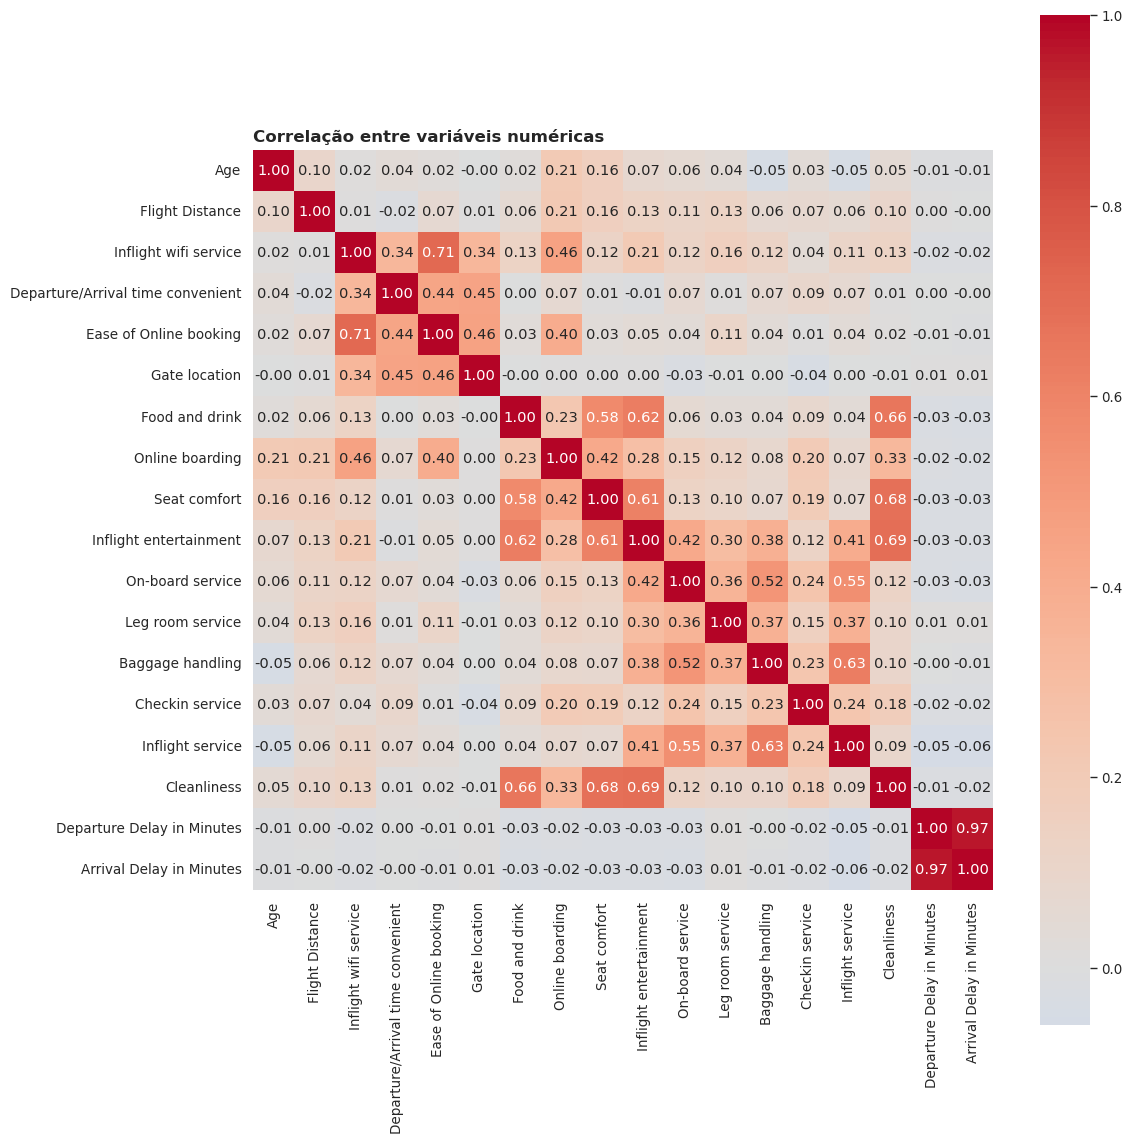

In [77]:
plt.figure(figsize=(12, 12))

# Cálculo da matriz de correlação para variáveis numéricas, ignorando colunas categóricas
corr_matrix = data.corr(numeric_only=True)

ax = sns.heatmap(
    data=corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    fmt=".2f",
)

# Definição do título do gráfico
ax.set_title(
    "Correlação entre variáveis numéricas",
    loc="left",
    fontsize=12,
    fontweight="bold",
)

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

Remoção da variável "Arrival Delay in Minutes" visando evitar a multicolinearidade:

In [78]:
# Remoçao da variável "Arrival Delay in Minutes" por apresentar alta correlação com a variável "Departure Delay in Minutes"
data.drop(columns=["Arrival Delay in Minutes"], inplace=True)

## Análise de Distribuição de Variáveis

A análise de distribuição de variáveis permite identificar a presença de distribuições assimétricas (skewed), que podem prejudicar modelos sensíveis à escala e à normalidade, como a regressão linear e logística. A identificação de assimetrias orienta a aplicação de transformações matemáticas, como logarítmicas ou de Box-Cox, para aproximar os dados de uma distribuição gaussiana, facilitando a convergência dos algoritmos de otimização (BROWNLEE, 2020, p. 165-167; GÉRON, 2019, p. 75-77).

Além disso, o estudo da distribuição é essencial para a detecção de outliers (valores atípicos), que podem distorcer as estimativas de parâmetros e aumentar o erro de generalização do modelo. Compreender como as variáveis se distribuem permite ao pesquisador decidir entre técnicas de escalonamento, como a padronização (standardization), que é preferível quando os dados seguem uma distribuição gaussiana, ou a normalização (normalization), que é mais robusta para distribuições variadas, garantindo que variáveis com diferentes ordens de magnitude contribuam de forma equilibrada para o modelo (ZHENG; CASARI, 2018, p. 29-31; BROWNLEE, 2016, p. 48-50).

A análise de distribuição auxilia, ainda, na identificação de variáveis com variância zero ou próxima de zero, as quais não adicionam valor informativo ao processo de aprendizado e podem ser removidas para reduzir a dimensionalidade e a complexidade computacional. Ao garantir que as distribuições das variáveis independentes nos conjuntos de treino e teste sejam consistentes, evita-se o fenômeno do *data leakage* e assegura-se que o modelo seja capaz de generalizar padrões para dados não observados de maneira eficaz (HUYEN, 2022, p. 124-126; DUBOUE, 2020, p. 34-36).

Para esta análise os dados das variáveis "Age", "Flight Distance" e "Departure Delay in Minutes" foram isolados, para melhor visualização das distribuições das demais variáveis, tendo em vista a discrepância de escalas entre estas, já sendo verificada a neessidade da aplicação de técnicas de escalonamento como a padronização (standardization) ou a normalização (normalization), de forma a equilibrar os dados para utilização no treinamento dos modelos.

Observando-se as variáveis relativas à satisfação com os serviços prestados pelas companhias aéreas verifica-se que os dados são distribuídos da maneira esperada, até mesmo porque estes dados, apesar de numéricos, tratam-se de dados categóricos ordinais com variação de valor de 0 a 5, não havendo necessidade de tratamento específico para estas variáveis.

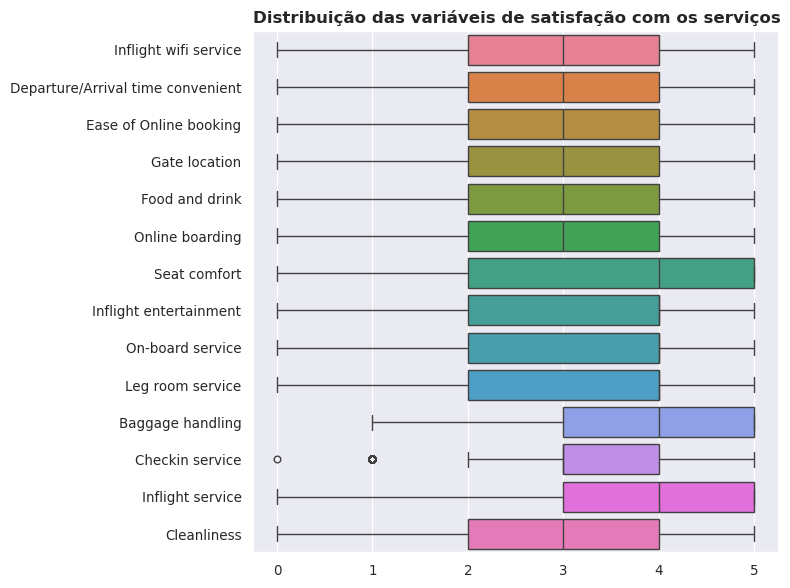

In [79]:
plt.figure(figsize=(8, 6))

ax = sns.boxplot(
    data=data.drop(
        columns=[
            "Age",
            "Flight Distance",
            "Departure Delay in Minutes",
        ]
    ),  # Remoção de variáveis para melhor visualização
    orient="h",
)

# Definição do título do gráfico
ax.set_title(
    "Distribuição das variáveis de satisfação com os serviços",
    loc="left",
    fontsize=12,
    fontweight="bold",
)

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

A variável "Age" também apreseta um comportamento próximo da normalidade, sem a presença de *outliers*, ocupando um range esperado para a distribuição de passageiros de uma companhia aérea. Neste caso também não há que se falar em necessidade de intervenção específica.

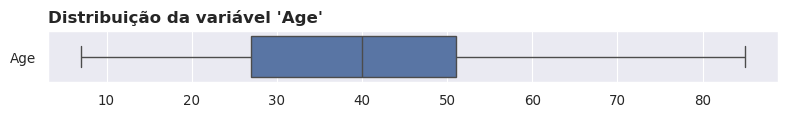

In [80]:
plt.figure(figsize=(8, 1.3))

ax = sns.boxplot(
    data=data[["Age"]],
    orient="h",
)

# Definição do título do gráfico
ax.set_title(
    "Distribuição da variável 'Age'",
    loc="left",
    fontsize=12,
    fontweight="bold",
)

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

A variável "Flight Distance", apesar de apresentar valores relativamente baixos, com mínimo de 31 milhas, e aparentes *outliers*, com o valor máximo de 4.983 milhas, ao serem comparados com informações disponíveis sobre o mercado de transporte aéreo são condizentes com rotas convencionais ativas, o que descarta a necessidade de exclusão de tais dados.

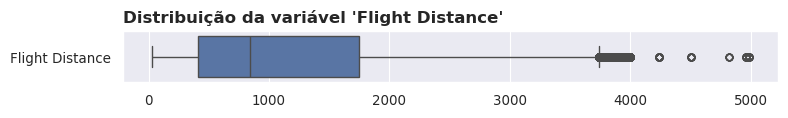

In [81]:
plt.figure(figsize=(8, 1.3))

ax = sns.boxplot(
    data=data[["Flight Distance"]],
    orient="h",
)

# Definição do título do gráfico
ax.set_title(
    "Distribuição da variável 'Flight Distance'",
    loc="left",
    fontsize=12,
    fontweight="bold",
)

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

In [82]:
data[["Flight Distance"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Flight Distance,129880.0,1190.316392,997.452477,31.0,414.0,844.0,1744.0,4983.0


A distribuição da variável "Departure Delay in Minutes" possui um comportamento assimétrico extremo, com uma curva assimétrica à direita (positiva), apresentando um comportamento característico da presença de *outliers*. De forma a evitar a remoção dos dados extremos, optou-se por empregar a Transformação Logarítmica à variável, utilizando a métrica de log(x + 1). Além disto, tendo em vista que a média e o desvio padrão são severamente distorcidos pelos valores extremos, optou-se pelo emprego do método RobustScaler para tratamento de pré-processamento dos dados.

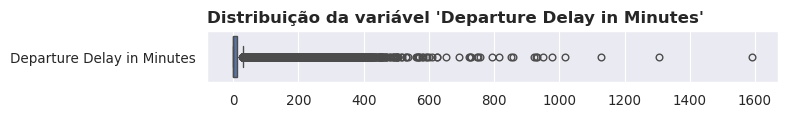

In [83]:
plt.figure(figsize=(8, 1.3))

ax = sns.boxplot(
    data=data[["Departure Delay in Minutes"]],
    orient="h",
)

# Definição do título do gráfico
ax.set_title(
    "Distribuição da variável 'Departure Delay in Minutes'",
    loc="left",
    fontsize=12,
    fontweight="bold",
)

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

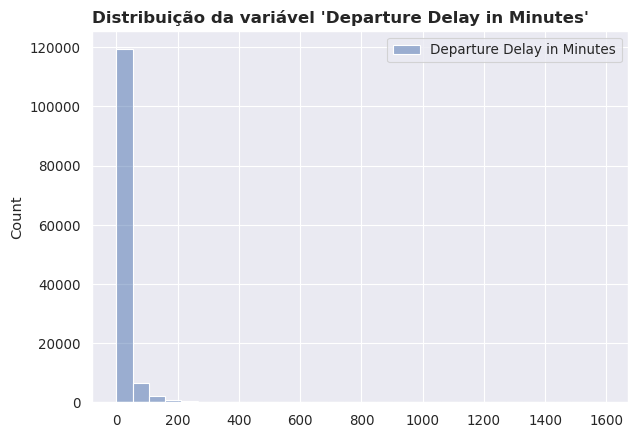

In [84]:
plt.figure(figsize=(6.5, 4.5))

ax = sns.histplot(
    data=data[["Departure Delay in Minutes"]],
    bins=30,
    stat="count",
)

# Definição do título do gráfico
ax.set_title(
    "Distribuição da variável 'Departure Delay in Minutes'",
    loc="left",
    fontsize=12,
    fontweight="bold",
)

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

In [85]:
data[["Departure Delay in Minutes"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Departure Delay in Minutes,129880.0,14.713713,38.071126,0.0,0.0,0.0,12.0,1592.0


Realizando a Transformação Logarítmica na variável "Departure Delay in Minutes", utilizando o método log1p (log(1 + x)) da bibliotena numpy.

In [86]:
data["Departure Delay in Minutes"] = np.log1p(
    data["Departure Delay in Minutes"]
)  # log1p calcula log(1 + x)

## Histogramas

...

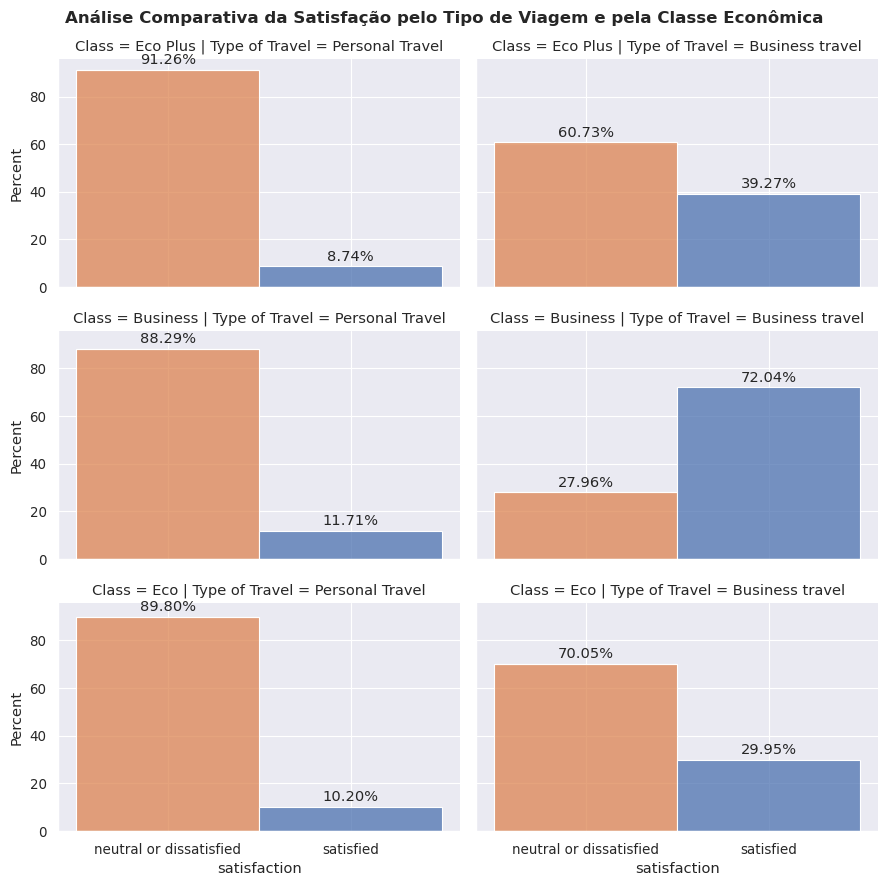

In [87]:
g = sns.FacetGrid(
    data=data,
    col="Type of Travel",
    row="Class",
    height=3,
    aspect=1.5,
    legend_out=False,
)

g.map_dataframe(
    sns.histplot,
    x="satisfaction",
    hue="satisfaction",
    hue_order=["satisfied", "neutral or dissatisfied"],
    stat="percent",
    multiple="stack",
)

g.figure.suptitle(
    "Análise Comparativa da Satisfação pelo Tipo de Viagem e pela Classe Econômica",
    fontsize=12,
    fontweight="bold",
)

# Iteração sobre os eixos para inclusão dos rótulos numéricos
for ax in g.axes.flatten():
    # Extração dos containers de barras do eixo atual
    for container in ax.containers:
        # Extração das alturas das barras e criação de rótulos condicionais
        labels = [f"{val:.2f}%" if val > 0 else "" for val in container.datavalues]

        # Aplicação dos rótulos filtrados ao container atual
        ax.bar_label(
            container,
            labels=labels,
            padding=2.0,
            label_type="edge",
        )

plt.tight_layout()
plt.show()

<div style="page-break-after: always;"></div>  

# XX. Pré-Processamento dos dados

...

<div style="page-break-after: always;"></div>  

# XX. Treinamento do Modelo

Como forma de validação do trabalho realizado foi procedido o treinamento de um modelo de Machine Learning de classificação, destinado à classificar o sentimento geral de satisfação de clientes de uma companhia aérea.

In [88]:
# # Treinamento de modelo de base para evolução posterior

# from autogluon.tabular import TabularPredictor

# # Definição da emente aleatória para reprodutibilidade dos resultados
# RANDOM_SEED = 42

# # Seleção dos modelos empregados
# custom_hyperparameters = {
#     "GBM": [{}],
#     "CAT": [{}],
#     "XGB": [{}],
# }

# # Treinamento do modelo de base utilizando AutoGluon
# predictor = TabularPredictor(
#     label="satisfaction",
#     path="../modelos/",
#     learner_kwargs={"random_state": RANDOM_SEED},
#     verbosity=0,
# ).fit(
#     train_data,
#     hyperparameters=custom_hyperparameters,
#     presets="medium",
#     time_limit=300,
#     verbosity=0,
# )

In [89]:
# # Análise dos modelos empregados e identificação do melhor modelo
# leaderboard = predictor.leaderboard(test_data, silent=True)
# display(leaderboard)

# # Análise de desempenho do melhor modelo
# performance = predictor.evaluate(test_data)

# print("Desempenho do melhor modelo:")
# print(f"Acurácia: {round(performance['accuracy'], 4)}")
# print(f"Precision: {round(performance['precision'], 4)}")
# print(f"F1 Score: {round(performance['f1'], 4)}")
# print(f"Recall: {round(performance['recall'], 4)}")

<div style="page-break-after: always;"></div>  

# XX. Conclusão

XXX ...

<div style="page-break-after: always;"></div>  

# Referências

BROWNLEE, Jason. **Data Preparation for Machine Learning**: Data Cleaning, Feature Selection, and Data Transforms in Python. [S.l.]: Machine Learning Mastery, 2020.

BROWNLEE, Jason. **Machine Learning Mastery with Python**: Understand Your Data, Create Accurate Models and Work Projects End-To-End. [S.l.]: Machine Learning Mastery, 2016.

BROWNLEE, Jason. **Statistical Methods for Machine Learning**: Discover How to Transform Data into Knowledge with Python. v. 1.4. [S.l.]: Machine Learning Mastery, 2019.

DUBOUE, Pablo. **The Art of Feature Engineering**: Essentials for Machine Learning. Cambridge: Cambridge University Press, 2020.

GEORGE, Jordan Goldmeier. **Advancing into Analytics**: From Excel to Python and R. Sebastopol: O'Reilly Media, 2021.

GÉRON, Aurélien. **Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow**: Concepts, Tools, and Techniques to Build Intelligent Systems. 2. ed. [S.l.]: O'Reilly Media, 2019.

HUYEN, Chip. **Designing Machine Learning Systems**: An Iterative Process for Production-Ready Applications. [S.l.]: O'Reilly Media, 2022.

VASQUES, Xavier. **Machine Learning Theory and Applications**: Hands-on Use Cases with Python on Classical and Quantum Machines. Hoboken, NJ: Wiley, 2024.

ZHENG, Alice; CASARI, Amanda. **Feature Engineering for Machine Learning**: Principles and Techniques for Data Scientists. [S. l.]: O'Reilly Media, 2018.